<a href="https://colab.research.google.com/github/SySyAli/amazon_fashion_nlp/blob/main/NLP_Project_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Syed Ali and Zayaan Rahman
# 3/22/2026
# Human NLP Project, Check in 2

# NOTE: this was made as a google colab notebook

In [ ]:
!pip install datasets pandas tqdm gensim umap-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.4 MB/s eta 0:00:00


In [ ]:
import re
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import umap

from datasets import load_dataset
from tqdm.auto import tqdm

from sklearn.utils import resample

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score

from gensim.models import Word2Vec

warnings.filterwarnings('ignore')

In [ ]:
AVAILABLE_CATS = [
    "All_Beauty", "Amazon_Fashion", "Appliances", "Arts_Crafts_and_Sewing",
    "Automotive", "Baby_Products", "Beauty_and_Personal_Care", "Books",
    "CDs_and_Vinyl", "Cell_Phones_and_Accessories", "Clothing_Shoes_and_Jewelry",
    "Digital_Music", "Electronics", "Gift_Cards", "Grocery_and_Gourmet_Food",
    "Handmade_Products", "Health_and_Household", "Health_and_Personal_Care",
    "Home_and_Kitchen", "Industrial_and_Scientific", "Kindle_Store",
    "Magazine_Subscriptions", "Movies_and_TV", "Musical_Instruments",
    "Office_Products", "Patio_Lawn_and_Garden", "Pet_Supplies", "Software",
    "Sports_and_Outdoors", "Subscription_Boxes", "Tools_and_Home_Improvement",
    "Toys_and_Games", "Video_Games",
]


DEFAULT_FIELDS = [
    "rating", "title", "text", "asin", "parent_asin",
    "user_id", "timestamp", "helpful_vote", "verified_purchase",
]

_pattern = re.compile(r"""
    <[^>]+>
    | \$\d+(?:\.\d+)?
    | \d+(?:\.\d+)?
    | [a-z]+(?:['\u2018\u2019][a-z]+)*
    | [a-z]+-[a-z]+
""", re.VERBOSE | re.IGNORECASE)

def tokenize(txt):

    if not isinstance(txt, str) or not txt.strip():
        return []

    return [t.lower() for t in _pattern.findall(txt) if not t.startswith('<')]


In [ ]:
def load_amazon_reviews(cats="Amazon_Fashion", max_rev=None, min_length=3,
                        ratings=None, fields=DEFAULT_FIELDS):

    if isinstance(cats, str):
        cats = [cats]

    per_cat = (max_rev // len(cats)) if max_rev else None
    frames = []

    for cat in cats:
        if cat not in AVAILABLE_CATS:
            raise ValueError(f"unknown cat '{cat}'")

        ds = load_dataset(
            "json",
            data_files=f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/{cat}.jsonl",
            split="train",
            streaming=True,
        )

        records = []

        with tqdm(total=per_cat, desc=cat) as pbar:

            for record in ds: # get can fail
                if len((record.get("text") or "").strip()) < min_length:
                    continue

                if ratings and record.get("rating") not in [float(r) for r in ratings]:
                    continue

                row = {f: record.get(f) for f in fields}
                row["category"] = cat

                records.append(row)
                pbar.update(1)

                if per_cat and len(records) >= per_cat:
                    break

        frames.append(pd.DataFrame(records))
    df = pd.concat(frames, ignore_index=True)

    df["timestamp_sec"] = df["timestamp"] / 1000
    df["rating_int"] = df["rating"].astype(int)
    df["helpful_vote"] = df["helpful_vote"].fillna(0).astype(int)

    print(f"loaded {df.shape[0]:,} rows  ratings {df['rating_int'].value_counts().sort_index().to_dict()}")

    return df


def balance_dataset(df, rating_col='rating_int', n_per_class=50000, seed=42):
    parts = []

    for rating in sorted(df[rating_col].unique()):

        subset = df[df[rating_col] == rating]
        n = min(n_per_class, len(subset))
        parts.append(resample(subset, replace=False, n_samples=n, random_state=seed))

    return pd.concat(parts).reset_index(drop=True)

In [ ]:
def tokenize_corpus(texts):

    return [tokenize(t) for t in texts]


def dataset_stats(token_lists, label=""):

    vocab = set(t for tokens in token_lists for t in tokens)
    total = sum(len(t) for t in token_lists)

    print(f"{label}  {len(token_lists):,} docs  {len(vocab):,} vocab  {total:,} tokens  avg {total/max(len(token_lists),1):.1f}")


def split_data(token_lists, labels, test_size=0.2, seed=42):

    train_tok, test_tok, y_train, y_test = train_test_split(
        token_lists, labels, test_size=test_size, random_state=seed, stratify=labels
    )

    print(f"train {len(train_tok):,} / test {len(test_tok):,}")
    return {'train_tok': train_tok, 'test_tok': test_tok,

            'y_train': y_train, 'y_test': y_test}

In [ ]:
def build_count_features(train_tok, test_tok, max_features=10000):

    vec = CountVectorizer(analyzer=lambda x: x, max_features=max_features, min_df=3)
    return vec.fit_transform(train_tok), vec.transform(test_tok), vec


def build_tfidf_features(train_tok, test_tok, max_features=15000, ngram_range=(1, 2)):

    vec = TfidfVectorizer(analyzer=lambda x: x, max_features=max_features,
                          ngram_range=ngram_range, sublinear_tf=True, min_df=3)
    return vec.fit_transform(train_tok), vec.transform(test_tok), vec


def build_w2v_features(train_tok, test_tok, vector_size=200, window=7, epochs=10):

    w2v = Word2Vec(sentences=train_tok, vector_size=vector_size, window=window,
                   min_count=3, sg=1, epochs=epochs, workers=4, seed=42)
    print(f"w2v vocab {len(w2v.wv):,} words")

    tfidf = TfidfVectorizer(analyzer=lambda x: x, min_df=2, sublinear_tf=True)
    tfidf.fit(train_tok)

    word2weight = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

    def vecs(token_lists):

        out = []
        for tokens in token_lists:
            vecs, weights = [], []
            for word in tokens:
                if word in w2v.wv and word in word2weight:
                    vecs.append(w2v.wv[word])
                    weights.append(word2weight[word])
            if not vecs:
                out.append(np.zeros(vector_size))
            else:
                v = np.array(vecs)
                w = np.array(weights).reshape(-1, 1)
                out.append(np.sum(v * w, axis=0) / np.sum(w))

        return np.array(out)

    return vecs(train_tok), vecs(test_tok), w2v


def train_and_evaluate(X_train, y_train, X_test, y_test, model_name="model"):

    clf = LogisticRegression(multi_class='multinomial', solver='saga',
                             max_iter=1500, C=1.0, n_jobs=-1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"\n--- {model_name} ---")
    print(classification_report(y_test, y_pred))


    return clf, y_pred

In [ ]:
def plot_summary_table(results, y_test):

    print(f"\n{'model':<35} {'acc':>8} {'macro f1':>10} {'wtd f1':>10}")
    print("-" * 65)

    for name, y_pred in results.items():

        acc = accuracy_score(y_test, y_pred)
        mf1 = f1_score(y_test, y_pred, average='macro')
        wf1 = f1_score(y_test, y_pred, average='weighted')

        print(f"{name:<35} {acc:>8.4f} {mf1:>10.4f} {wf1:>10.4f}")


def plot_f1_comparison(results, y_test, title, filename=None):

    classes = sorted(np.unique(y_test))
    x = np.arange(len(classes))
    width = 0.25

    colors = ['#2196F3', '#FF9800', '#4CAF50'] # from other work for graph

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (name, y_pred) in enumerate(results.items()):

        report = classification_report(y_test, y_pred, output_dict=True)
        f1s = [report.get(str(c), {}).get('f1-score', 0.0) for c in classes]
        ax.bar(x + i * width, f1s, width, label=name, color=colors[i % len(colors)])

    ax.set_xlabel('Rating Class')
    ax.set_ylabel('F1 Score')
    ax.set_title(title)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'{c}-star' for c in classes])
    ax.legend(loc='upper left', fontsize=9)
    ax.set_ylim(0, 1)
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


def plot_word_embeddings(w2v_model, title, filename=None):

    word_groups = { # from previous part
        'Positive Sentiment': ['love', 'perfect', 'excellent', 'amazing', 'comfortable'],
        'Negative Sentiment': ['terrible', 'awful', 'disappointing', 'cheap', 'useless'],
        'Quality / Material': ['soft', 'durable', 'lightweight', 'breathable', 'leather'],
        'Fit / Sizing':       ['tight', 'loose', 'snug', 'oversized', 'narrow'],
        'Window 1 (14-16)':   ['discount', 'exchange', 'honest', 'fake', 'misleading',
                               'ridiculous', 'wallet', 'clasp', 'bent', 'wasted'],
        'Window 2 (17-19)':   ['expected', 'sewn', 'stuck', 'zipper'],
        'Window 3 (20-22)':   ['adjustable', 'everyday', 'advertised', 'false',
                               'photo', 'seller', 'surprised', 'china'],
    }
    colors = ['#EF476F', '#FFD166', '#06D6A0', '#118AB2', '#073B4C', '#B5838D', '#F4A261']

    words, labels = [], []
    for i, (group, word_list) in enumerate(word_groups.items()):

        for w in word_list:
            if w in w2v_model.wv:
                words.append(w)
                labels.append(group)

    vectors = np.array([w2v_model.wv[w] for w in words])

    # note: AI assistance used for UMAP visualization
    coords = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(vectors)
    labels_arr = np.array(labels)
    fig, ax = plt.subplots(figsize=(14, 10))

    for i, group in enumerate(word_groups.keys()):
        mask = labels_arr == group
        ax.scatter(coords[mask, 0], coords[mask, 1], c=colors[i],
                   label=group, s=100, alpha=0.7, edgecolors='white')

    for j, word in enumerate(words):
        ax.annotate(word, (coords[j, 0], coords[j, 1]), fontsize=9, alpha=0.8,
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

    ax.set_title(title, fontsize=14)
    ax.legend(title='Word Category', loc='best', fontsize=9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
amazon_df = load_amazon_reviews(cats="Amazon_Fashion")

Amazon_Fashion: 0it [00:00, ?it/s]

loaded 2,492,799 rows  ratings {1: 302814, 2: 173191, 3: 244590, 4: 351153, 5: 1421051}


In [ ]:
df_binary = balance_dataset(
    amazon_df[amazon_df['rating_int'].isin([1, 5])].copy(),
    n_per_class=100000
)

df_5class = balance_dataset(amazon_df, n_per_class=50000)

print(f"binary   {len(df_binary):,}  {df_binary['rating_int'].value_counts().sort_index().to_dict()}")
print(f"5-class  {len(df_5class):,}  {df_5class['rating_int'].value_counts().sort_index().to_dict()}")


binary   200,000  {1: 100000, 5: 100000}
5-class  250,000  {1: 50000, 2: 50000, 3: 50000, 4: 50000, 5: 50000}


In [ ]:
bin_tokens = tokenize_corpus(df_binary['text'])
dataset_stats(bin_tokens, 'binary')
bin_splits = split_data(bin_tokens, df_binary['rating_int'].values)

train_tok_bin = bin_splits['train_tok']
test_tok_bin  = bin_splits['test_tok']

y_train_bin   = bin_splits['y_train']
y_test_bin    = bin_splits['y_test']

binary  200,000 docs  43,668 vocab  5,102,226 tokens  avg 25.5
train 160,000 / test 40,000


In [ ]:
X_train_count_bin, X_test_count_bin, _ = build_count_features(train_tok_bin, test_tok_bin)
_, y_pred_count_bin = train_and_evaluate(
    X_train_count_bin, y_train_bin, X_test_count_bin, y_test_bin,
    'countvec binary'
)


--- countvec binary ---
              precision    recall  f1-score   support

           1       0.95      0.95      0.95     20000
           5       0.95      0.95      0.95     20000

    accuracy                           0.95     40000
   macro avg       0.95      0.95      0.95     40000
weighted avg       0.95      0.95      0.95     40000



In [ ]:
X_train_tfidf_bin, X_test_tfidf_bin, _ = build_tfidf_features(train_tok_bin, test_tok_bin)
_, y_pred_tfidf_bin = train_and_evaluate(

    X_train_tfidf_bin, y_train_bin, X_test_tfidf_bin, y_test_bin,
    'tfidf 1+2gram binary'
)


--- tfidf 1+2gram binary ---
              precision    recall  f1-score   support

           1       0.95      0.96      0.95     20000
           5       0.96      0.95      0.95     20000

    accuracy                           0.95     40000
   macro avg       0.95      0.95      0.95     40000
weighted avg       0.95      0.95      0.95     40000



In [ ]:
X_train_w2v_bin, X_test_w2v_bin, w2v_bin = build_w2v_features(train_tok_bin, test_tok_bin)

for word in ['soft', 'terrible', 'cheap', 'quality']:

    if word in w2v_bin.wv:
        sims = w2v_bin.wv.most_similar(word, topn=4)
        print(f"  {word}: {', '.join(f'{w}({s:.2f})' for w, s in sims)}")

_, y_pred_w2v_bin = train_and_evaluate(
    X_train_w2v_bin, y_train_bin, X_test_w2v_bin, y_test_bin,
    'w2v 200d binary'
)

w2v vocab 15,696 words
  soft: cozy(0.66), cuddly(0.63), buttery(0.63), comfotable(0.62)
  terrible: horrible(0.85), awful(0.71), poor(0.65), horrid(0.64)
  cheap: cheep(0.72), cheaply(0.71), chintzy(0.69), cheesey(0.68)
  quality: workmanship(0.60), quility(0.60), craftsmanship(0.60), quailty(0.59)

--- w2v 200d binary ---
              precision    recall  f1-score   support

           1       0.93      0.94      0.94     20000
           5       0.94      0.93      0.94     20000

    accuracy                           0.94     40000
   macro avg       0.94      0.94      0.94     40000
weighted avg       0.94      0.94      0.94     40000




model                                    acc   macro f1     wtd f1
-----------------------------------------------------------------
CountVectorizer (1-gram)              0.9496     0.9496     0.9496
TF-IDF (1+2gram)                      0.9536     0.9536     0.9536
Word2Vec (200d)                       0.9362     0.9362     0.9362


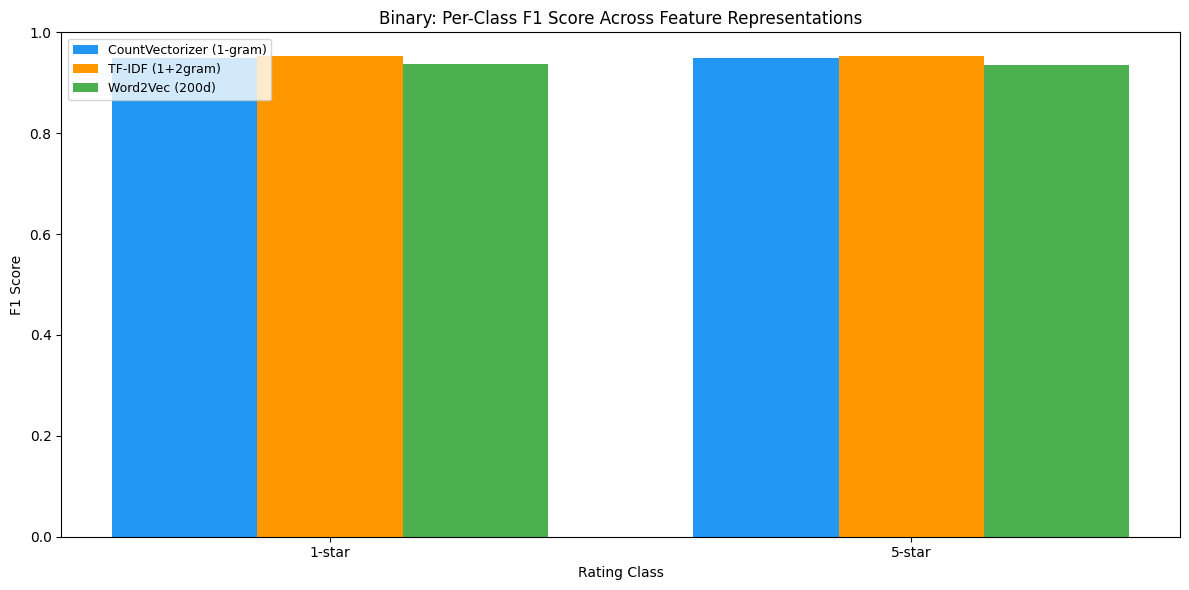

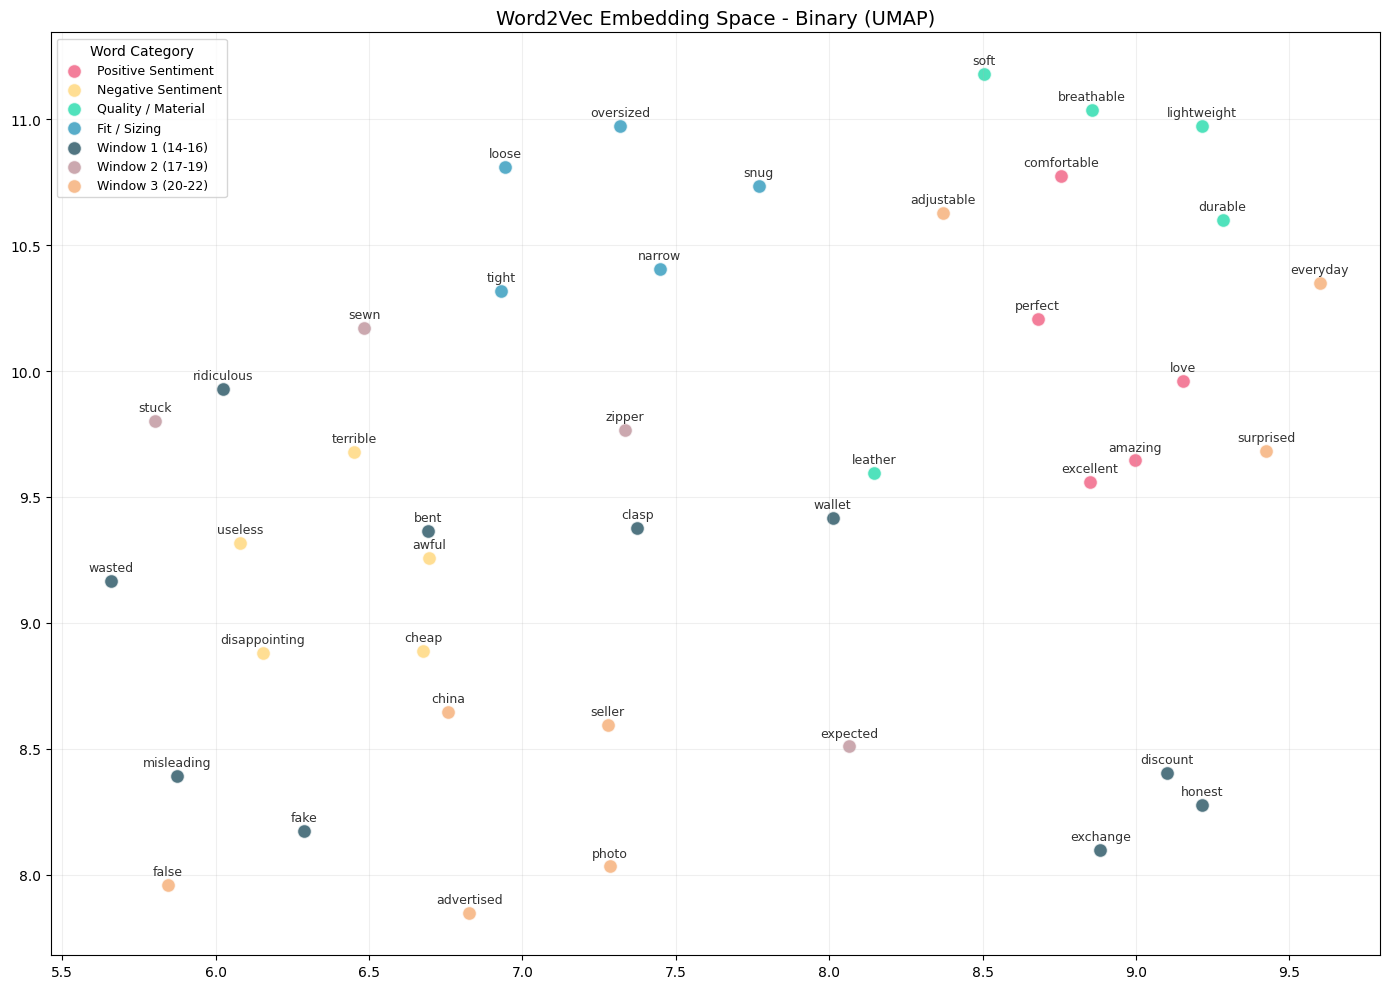

In [ ]:
results_bin = {

    'CountVectorizer (1-gram)': y_pred_count_bin,
    'TF-IDF (1+2gram)':         y_pred_tfidf_bin,
    'Word2Vec (200d)':           y_pred_w2v_bin,
}

plot_summary_table(results_bin, y_test_bin)
plot_f1_comparison(results_bin, y_test_bin,
                   title='Binary: Per-Class F1 Score Across Feature Representations',
                   filename='binary_f1_comparison.png')

plot_word_embeddings(w2v_bin,
                     title='Word2Vec Embedding Space - Binary (UMAP)',
                     filename='binary_umap.png')

In [ ]:
tokens_5c = tokenize_corpus(df_5class['text'])
dataset_stats(tokens_5c, '5-class')
splits_5c = split_data(tokens_5c, df_5class['rating_int'].values)

train_tok_5c = splits_5c['train_tok']
test_tok_5c  = splits_5c['test_tok']


y_train_5c   = splits_5c['y_train']
y_test_5c    = splits_5c['y_test']

5-class  250,000 docs  48,474 vocab  7,548,688 tokens  avg 30.2
train 200,000 / test 50,000


In [ ]:
X_train_count_5c, X_test_count_5c, _ = build_count_features(train_tok_5c, test_tok_5c)

_, y_pred_count_5c = train_and_evaluate(
    X_train_count_5c, y_train_5c, X_test_count_5c, y_test_5c,
    'countvec 5-class'
)


--- countvec 5-class ---
              precision    recall  f1-score   support

           1       0.55      0.67      0.60     10000
           2       0.39      0.32      0.35     10000
           3       0.41      0.37      0.39     10000
           4       0.49      0.42      0.45     10000
           5       0.65      0.78      0.71     10000

    accuracy                           0.51     50000
   macro avg       0.50      0.51      0.50     50000
weighted avg       0.50      0.51      0.50     50000



In [ ]:
X_train_tfidf_5c, X_test_tfidf_5c, _ = build_tfidf_features(train_tok_5c, test_tok_5c)

_, y_pred_tfidf_5c = train_and_evaluate(
    X_train_tfidf_5c, y_train_5c, X_test_tfidf_5c, y_test_5c,
    'tfidf 1+2gram 5-class'
)


--- tfidf 1+2gram 5-class ---
              precision    recall  f1-score   support

           1       0.57      0.65      0.61     10000
           2       0.39      0.36      0.37     10000
           3       0.41      0.39      0.40     10000
           4       0.50      0.45      0.48     10000
           5       0.69      0.75      0.72     10000

    accuracy                           0.52     50000
   macro avg       0.51      0.52      0.52     50000
weighted avg       0.51      0.52      0.52     50000



In [ ]:
X_train_w2v_5c, X_test_w2v_5c, w2v_5c = build_w2v_features(train_tok_5c, test_tok_5c)

for word in ['soft', 'terrible', 'cheap', 'quality']:
    if word in w2v_5c.wv:
        sims = w2v_5c.wv.most_similar(word, topn=4)
        print(f"  {word}: {', '.join(f'{w}({s:.2f})' for w, s in sims)}")

_, y_pred_w2v_5c = train_and_evaluate(
    X_train_w2v_5c, y_train_5c, X_test_w2v_5c, y_test_5c,
    'w2v 200d 5-class'
)

w2v vocab 17,950 words
  soft: buttery(0.66), cozy(0.63), stretchy(0.63), comfy(0.62)
  terrible: horrible(0.81), awful(0.69), poor(0.63), bad(0.56)
  cheap: cheaply(0.71), cheep(0.70), flimsy(0.69), cheezy(0.66)
  quality: quailty(0.66), workmanship(0.59), craftmanship(0.59), craftsmanship(0.58)

--- w2v 200d 5-class ---
              precision    recall  f1-score   support

           1       0.55      0.61      0.58     10000
           2       0.38      0.34      0.36     10000
           3       0.38      0.37      0.38     10000
           4       0.45      0.44      0.44     10000
           5       0.66      0.69      0.67     10000

    accuracy                           0.49     50000
   macro avg       0.49      0.49      0.49     50000
weighted avg       0.49      0.49      0.49     50000




model                                    acc   macro f1     wtd f1
-----------------------------------------------------------------
CountVectorizer (1-gram)              0.5122     0.5015     0.5015
TF-IDF (1+2gram)                      0.5209     0.5155     0.5155
Word2Vec (200d)                       0.4911     0.4875     0.4875


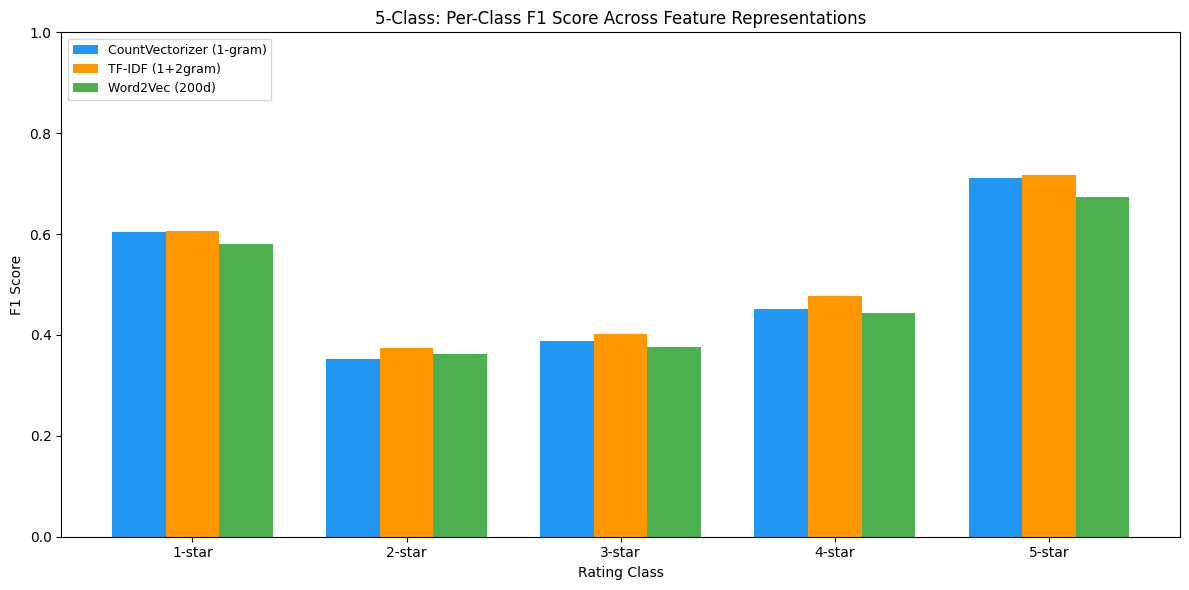

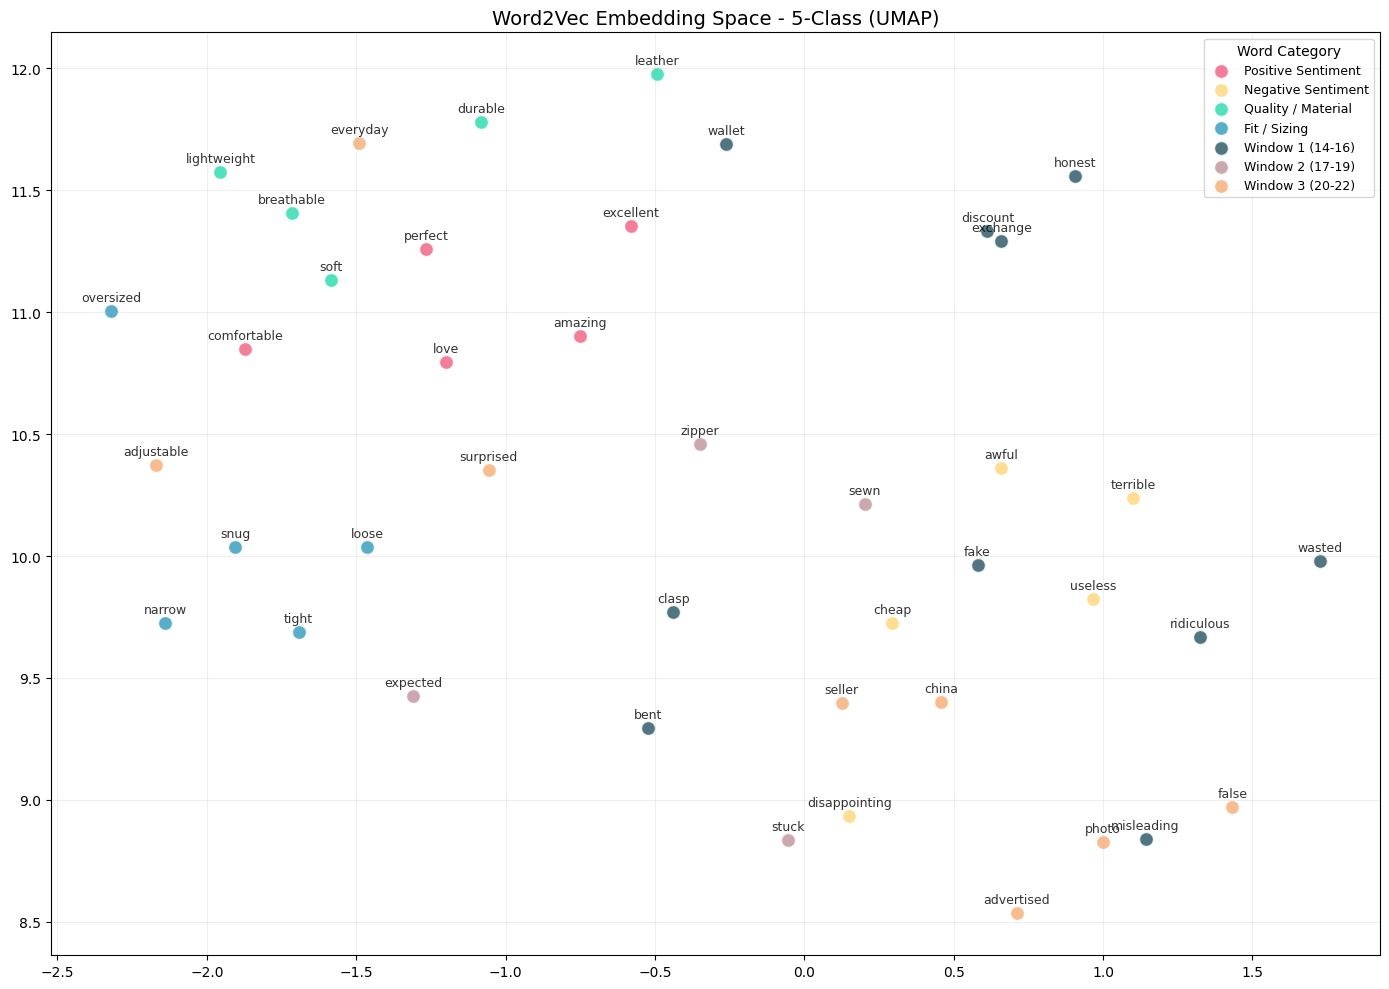

In [ ]:
results_5c = {
    'CountVectorizer (1-gram)': y_pred_count_5c,
    'TF-IDF (1+2gram)':         y_pred_tfidf_5c,
    'Word2Vec (200d)':           y_pred_w2v_5c,
}

plot_summary_table(results_5c, y_test_5c)
plot_f1_comparison(results_5c, y_test_5c,
                   title='5-Class: Per-Class F1 Score Across Feature Representations',
                   filename='5class_f1_comparison.png')


plot_word_embeddings(w2v_5c,
                     title='Word2Vec Embedding Space - 5-Class (UMAP)',
                     filename='5class_umap.png')

In [ ]:
# note random seed variation

In [ ]:
# make hypothetical bar charts
def mockup_bert(fname='mock_f1_scores.png'):
    cats = ['1 star', '2 star', '3 star', '4 star', '5 star']

    tfidf_f1 = [0.61, 0.37, 0.40, 0.48, 0.72]
    w2v_f1   = [0.58, 0.36, 0.38, 0.44, 0.67]
    bert_f1  = [0.69, 0.49, 0.51, 0.56, 0.79] # hypotehtical

    x = np.arange(len(cats))
    w = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    b1 = ax.bar(x - w, tfidf_f1, w, label='tfidf + logreg',
                color='#e67e22', edgecolor='white', linewidth=0.5)

    b2 = ax.bar(x,     w2v_f1,   w, label='word2vec + logreg',
                color='#2ecc71', edgecolor='white', linewidth=0.5)

    b3 = ax.bar(x + w, bert_f1,  w, label='distilbert (hypothetical)',
                color='#9b59b6', edgecolor='white', linewidth=0.5)

    ax.set_xlabel('rating class', fontsize=12)
    ax.set_ylabel('f1 score', fontsize=12)
    ax.set_title('mockup: per class f1 comparison 5 class\n(hypothetical bert results)',
                 fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(cats, fontsize=11)
    ax.legend(fontsize=9, loc='upper left')
    ax.set_ylim(0, 0.95)

    for bars in [b1, b2, b3]:
        for bar in bars:

            h = bar.get_height()

            ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', va='bottom', fontsize=7.5)

    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"saved {fname}")


def mockup_temporal(fname='mockup_temporal_drift.png'):
    logreg_acc = np.array([
        [0.53, 0.49, 0.45],
        [0.48, 0.52, 0.49],
        [0.44, 0.48, 0.54],
    ])

    bert_acc = np.array([ # hypotehtical
        [0.59, 0.55, 0.51],
        [0.54, 0.58, 0.55],
        [0.50, 0.54, 0.60],
    ])

    windows = ['2014 2016', '2017 2019', '2020 2022']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

    for ax, data, title, cmap in [
        (ax1, logreg_acc, 'tfidf + logreg',          'YlOrRd'),
        (ax2, bert_acc,   'distilbert (hypothetical)', 'PuBuGn'),
    ]:
        im = ax.imshow(data, cmap=cmap, vmin=0.40, vmax=0.62)

        ax.set_xticks(range(3))
        ax.set_yticks(range(3))

        ax.set_xticklabels(windows, fontsize=9)
        ax.set_yticklabels(windows, fontsize=9)

        ax.set_xlabel('test window', fontsize=11, fontweight='bold')
        ax.set_ylabel('train window', fontsize=11, fontweight='bold')
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

        for i in range(3):
            for j in range(3):

                v = data[i, j]

                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=13, fontweight='bold' if i == j else 'normal',
                        color='white' if v > 0.54 else 'black')

        plt.colorbar(im, ax=ax, shrink=0.8, label='5 class accuracy')

    fig.suptitle('mockup: cross window temporal drift logreg vs bert\n(hypothetical results)',
                 fontsize=12, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"saved {fname}")

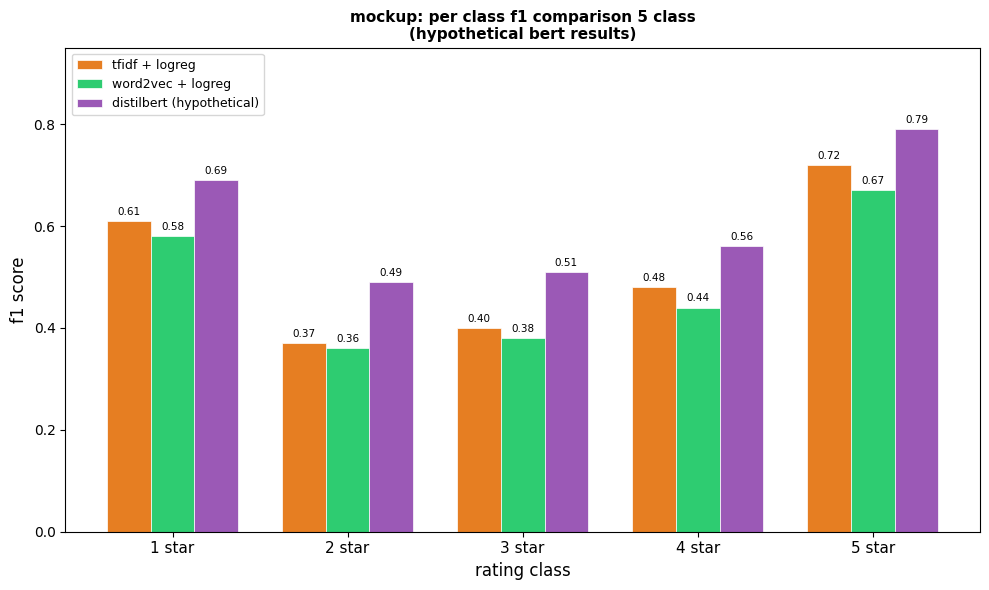

saved mock_f1_scores.png


In [ ]:
mockup_bert()

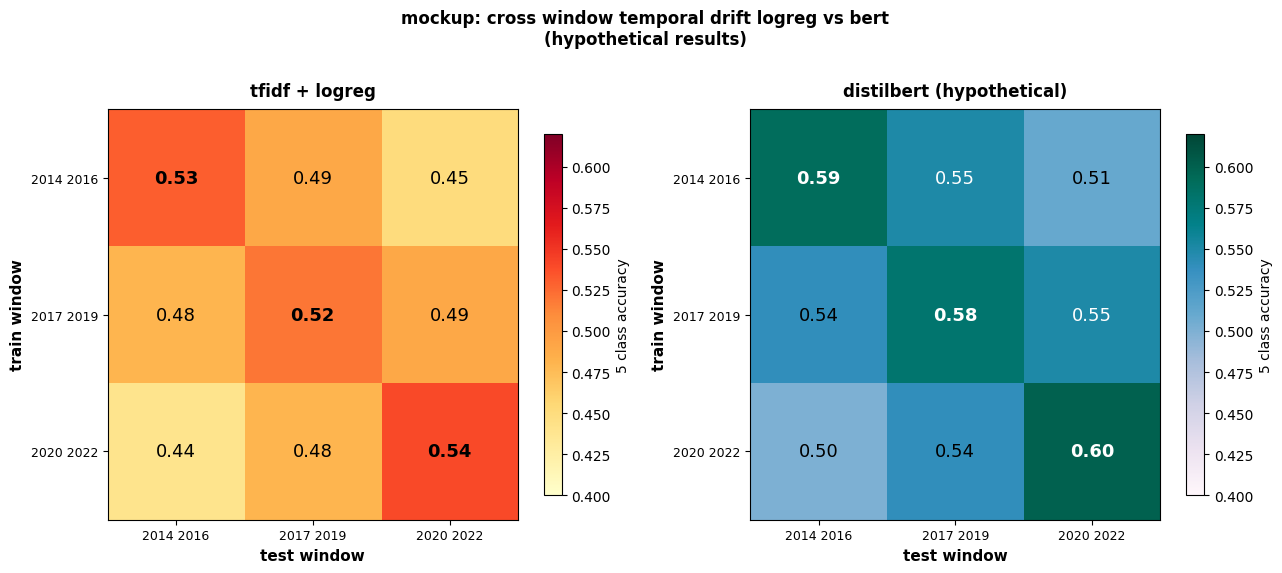

saved mockup_temporal_drift.png


In [ ]:
mockup_temporal()